In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/resnet_features_preprocessed.csv')

In [ ]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_2039,feature_2040,feature_2041,feature_2042,feature_2043,feature_2044,feature_2045,feature_2046,feature_2047,label
0,0.039164,0.617642,0.107853,0.376942,0.089375,0.042309,0.135151,0.246696,0.143043,0.216616,...,0.265314,0.518185,0.623599,0.150417,0.017330,0.218101,0.447609,0.877618,0.249591,AD
1,0.253862,0.289451,0.183565,0.503103,0.039190,0.039847,0.640761,0.352711,0.710503,0.498195,...,0.012770,0.620834,0.281454,0.323947,0.003298,0.073039,0.590564,1.009496,1.523529,AD
2,0.167927,0.537961,0.123549,0.713740,0.080809,0.513323,0.790639,0.229424,0.334899,0.273876,...,0.010286,0.851536,0.294417,0.066262,0.002479,0.108432,0.983083,0.705193,1.205853,AD
3,0.155322,0.372970,0.098443,0.384186,0.039190,0.006767,0.399594,0.515298,0.849680,0.412460,...,0.022496,0.642848,0.213399,0.262902,0.013065,0.014067,0.698723,0.844151,1.481523,AD
4,0.120427,0.113370,0.089176,0.423628,0.000719,0.041530,0.666011,0.591804,0.625362,0.500816,...,0.018377,0.751583,0.114963,0.364352,0.025591,0.002929,0.731588,1.326745,1.401907,AD


# Task
Split the `df` DataFrame into features (X) and labels (y), then further split the data into training, validation, and test sets with a 70:15:15 ratio respectively, ensuring stratification by the 'label' column.

## Prepare data for splitting

### Subtask:
Separate the features (X) from the labels (y) in the dataframe.


**Reasoning**:
To separate the features (X) from the labels (y), I will drop the 'label' column from the DataFrame to create X, and assign the 'label' column to y.



In [ ]:
X = df.drop('label', axis=1)
y = df['label']

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Shape of X: (3898, 2048)
Shape of y: (3898,)


## Split data into training and temporary sets

### Subtask:
Divide the data into a training set and a temporary set (which will later be split into validation and test sets), ensuring stratification by the 'label' column. This initial split will allocate 70% to training and 30% to the temporary set.


**Reasoning**:
The subtask requires splitting the data into training and temporary sets, ensuring stratification. Importing `train_test_split` is the first step to achieve this.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Shape of X_train:', X_train.shape)
print('Shape of X_temp:', X_temp.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_temp:', y_temp.shape)

Shape of X_train: (2728, 2048)
Shape of X_temp: (1170, 2048)
Shape of y_train: (2728,)
Shape of y_temp: (1170,)


In [ ]:
print('Label distribution in y_train:')
print(y_train.value_counts())
print('\nLabel distribution in y_temp:')
print(y_temp.value_counts())

Label distribution in y_train:
label
AD     1081
MCI     866
CN      781
Name: count, dtype: int64

Label distribution in y_temp:
label
AD     463
MCI    372
CN     335
Name: count, dtype: int64


In [ ]:
# Split temporary set into validation and test (15% / 15%) with stratification
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print('X_val:', X_val.shape, 'X_test:', X_test.shape)
print('y_val:', y_val.shape, 'y_test:', y_test.shape)

X_val: (585, 2048) X_test: (585, 2048)
y_val: (585,) y_test: (585,)


In [ ]:
print('Label distribution in y_train:')
print(y_train.value_counts())
print('\nLabel distribution in y_val:')
print(y_val.value_counts())
print('\nLabel distribution in y_test:')
print(y_test.value_counts())

Label distribution in y_train:
label
AD     1081
MCI     866
CN      781
Name: count, dtype: int64

Label distribution in y_val:
label
AD     231
MCI    186
CN     168
Name: count, dtype: int64

Label distribution in y_test:
label
AD     232
MCI    186
CN     167
Name: count, dtype: int64


In [ ]:
# Encode labels (AD, CN, MCI) to integers for modeling
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
class_names = list(le.classes_)
print('Classes:', class_names)

Classes: ['AD', 'CN', 'MCI']


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ----------------------------------------------------------
# Device Setup
# ----------------------------------------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------------------------------------
# Helper function
# ----------------------------------------------------------
def get_numpy_array(data):
    if isinstance(data, (pd.DataFrame, pd.Series)):
        return data.values
    elif isinstance(data, torch.Tensor):
        return data.cpu().numpy()
    elif isinstance(data, np.ndarray):
        return data
    else:
        raise TypeError(f"Unsupported type: {type(data)}")

# ----------------------------------------------------------
# Use existing train/val/test splits from earlier cells
# ----------------------------------------------------------
# Convert to Tensors
X_train_tensor = torch.from_numpy(get_numpy_array(X_train)).float().to(device)
y_train_tensor = torch.from_numpy(get_numpy_array(y_train_enc)).long().to(device)
X_val_tensor = torch.from_numpy(get_numpy_array(X_val)).float().to(device)
y_val_tensor = torch.from_numpy(get_numpy_array(y_val_enc)).long().to(device)
X_test_tensor = torch.from_numpy(get_numpy_array(X_test)).float().to(device)
y_test_tensor = torch.from_numpy(get_numpy_array(y_test_enc)).long().to(device)

INPUT_SIZE = X_train_tensor.shape[1]
OUTPUT_SIZE = int(torch.max(y_train_tensor).item() + 1)
criterion = nn.CrossEntropyLoss()

print(f"Input size: {INPUT_SIZE}, Output size: {OUTPUT_SIZE}")
print(f"Train: {X_train_tensor.shape}, Val: {X_val_tensor.shape}, Test: {X_test_tensor.shape}")

# ----------------------------------------------------------
# Define RVFL Model
# ----------------------------------------------------------
class RVFL(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RVFL, self).__init__()
        self.linear_dir = nn.Linear(input_size, output_size, bias=True)
        self.linear_hidden = nn.Linear(input_size, hidden_size, bias=True)
        self.linear_hidden_out = nn.Linear(hidden_size, output_size, bias=True)
        self.act_hidden = nn.Sigmoid()

    def forward(self, x):
        dir_data = self.linear_dir(x)
        hidden_data = self.act_hidden(self.linear_hidden(x))
        feature = torch.cat((hidden_data, x), -1)
        hidden_out = self.linear_hidden_out(hidden_data)
        return feature, dir_data + hidden_out

# ----------------------------------------------------------
# Evaluation Function
# ----------------------------------------------------------
def evaluate(model, X, y):
    _, pred = model(X)
    loss = criterion(pred, y)
    pred_label = torch.max(pred, 1)[1]
    acc = torch.sum(pred_label == y).item() / y.shape[0]
    return acc, loss.item()

# ----------------------------------------------------------
# Hyperparameter Search
# ----------------------------------------------------------
hidden_sizes = [20]#], 50,100,200,500]

# Wider range for lambda (regularization strength)
# covers very small (1e-8) to large (10) values
#lambdas = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000, 1000000, 10000000]
lambdas = [ 10]
best_acc = 0
best_config = None

search_results = []

for HIDDEN in hidden_sizes:
    for LAMBDA in lambdas:
        rvfl = RVFL(INPUT_SIZE, HIDDEN, OUTPUT_SIZE).to(device)
        rvfl.eval()

        # One-hot encode labels
        Y = torch.zeros(y_train_tensor.shape[0], OUTPUT_SIZE, device=device).scatter_(
            1, y_train_tensor.reshape(-1, 1), 1
        )

        # Forward pass
        out_feature, _ = rvfl(X_train_tensor)

        # Closed-form solution (ridge regression)
        I = torch.eye(out_feature.shape[1], device=device)
        W = torch.mm(
            torch.mm(torch.inverse(LAMBDA * I + torch.mm(out_feature.t(), out_feature)), out_feature.t()),
            Y,
        ).t()

        # Assign weights
        with torch.no_grad():
            rvfl.linear_hidden_out.weight.copy_(W[:, 0:HIDDEN])
            rvfl.linear_dir.weight.copy_(W[:, HIDDEN:])

        # Evaluate train/val/test
        train_acc, train_loss = evaluate(rvfl, X_train_tensor, y_train_tensor)
        val_acc, val_loss = evaluate(rvfl, X_val_tensor, y_val_tensor)
        test_acc, test_loss = evaluate(rvfl, X_test_tensor, y_test_tensor)

        # Log results
        search_results.append({
            "hidden": HIDDEN,
            "lambda": LAMBDA,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "test_acc": test_acc
        })

        print(
            f"H={HIDDEN:<4} | λ={LAMBDA:<6} | "
            f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Test Acc={test_acc:.4f}"
        )

        # Track best based on validation accuracy
        if val_acc > best_acc:
            best_acc = val_acc
            best_config = (HIDDEN, LAMBDA, train_acc, val_acc)

# ----------------------------------------------------------
# Final Evaluation on Test Set
# ----------------------------------------------------------
print("\nBest Config:")
print(
    f"HIDDEN={best_config[0]}, LAMBDA={best_config[1]}, "
    f"Train Acc={best_config[2]:.4f}, Val Acc={best_config[3]:.4f}"
)

# Re-train with best config on train+val
best_hidden, best_lambda = best_config[0], best_config[1]
rvfl_best = RVFL(INPUT_SIZE, best_hidden, OUTPUT_SIZE).to(device)
rvfl_best.eval()

X_combined = torch.cat((X_train_tensor, X_val_tensor), dim=0)
y_combined = torch.cat((y_train_tensor, y_val_tensor), dim=0)

Y_combined = torch.zeros(y_combined.shape[0], OUTPUT_SIZE, device=device).scatter_(
    1, y_combined.reshape(-1, 1), 1
)

out_feature, _ = rvfl_best(X_combined)
I = torch.eye(out_feature.shape[1], device=device)
W = torch.mm(
    torch.mm(torch.inverse(best_lambda * I + torch.mm(out_feature.t(), out_feature)), out_feature.t()),
    Y_combined,
).t()

with torch.no_grad():
    rvfl_best.linear_hidden_out.weight.copy_(W[:, 0:best_hidden])
    rvfl_best.linear_dir.weight.copy_(W[:, best_hidden:])

# Final test accuracy
test_acc, test_loss = evaluate(rvfl_best, X_test_tensor, y_test_tensor)
print(f"Final Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Device: cpu
Input size: 2048, Output size: 3
Train: torch.Size([2728, 2048]), Val: torch.Size([585, 2048]), Test: torch.Size([585, 2048])
H=20   | λ=10     | Train Acc=0.9934 | Val Acc=0.9504 | Test Acc=0.9436

Best Config:
HIDDEN=20, LAMBDA=10, Train Acc=0.9934, Val Acc=0.9504
Final Test Accuracy: 0.9590, Test Loss: 0.6713


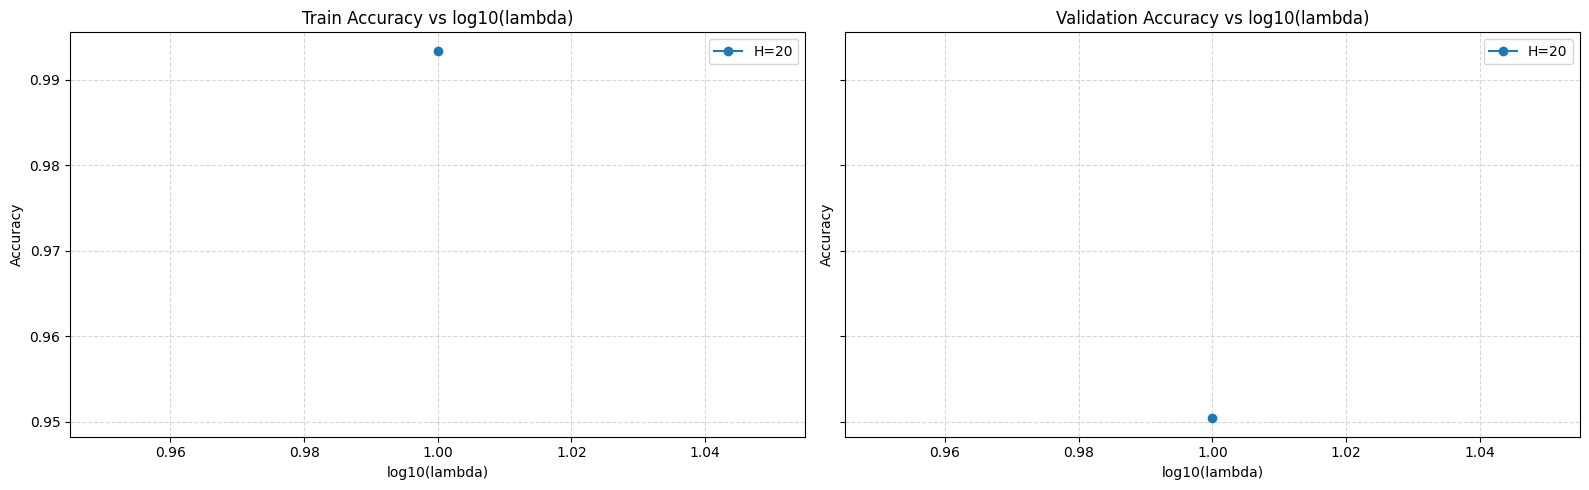

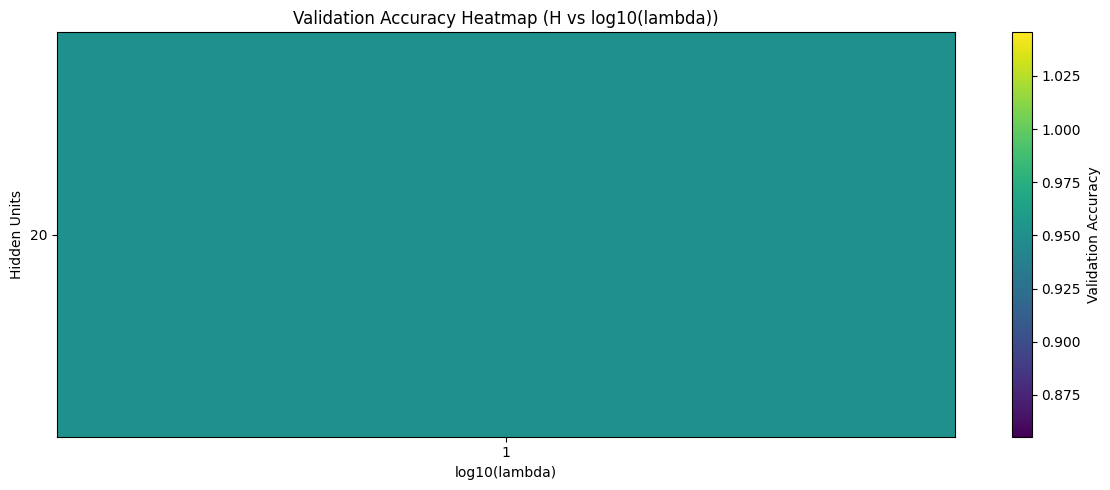

In [ ]:
# Train vs Validation Accuracy across Hyperparameters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure search_results exists from the previous cell
assert 'search_results' in globals() and len(search_results) > 0, "Run the hyperparameter search cell first."

results_df = pd.DataFrame(search_results)
results_df = results_df.sort_values(["hidden", "lambda"]).reset_index(drop=True)

# Numeric x-axis on log10(lambda)
results_df["log10_lambda"] = np.log10(results_df["lambda"].astype(float))

hidden_values = sorted(results_df["hidden"].unique().tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

for h in hidden_values:
    sub = results_df[results_df["hidden"] == h].sort_values("lambda")
    axes[0].plot(sub["log10_lambda"], sub["train_acc"], marker='o', label=f"H={h}")
    axes[1].plot(sub["log10_lambda"], sub["val_acc"], marker='o', label=f"H={h}")

axes[0].set_title("Train Accuracy vs log10(lambda)")
axes[1].set_title("Validation Accuracy vs log10(lambda)")
for ax in axes:
    ax.set_xlabel("log10(lambda)")
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

# Optional: Heatmap of Validation Accuracy
try:
    # Pivot: rows=hidden, cols=log10_lambda
    heat_df = results_df.pivot(index="hidden", columns="log10_lambda", values="val_acc")
    plt.figure(figsize=(12, 5))
    im = plt.imshow(heat_df.values, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(im, label='Validation Accuracy')
    plt.yticks(ticks=np.arange(len(heat_df.index)), labels=heat_df.index)
    # Show a limited number of x ticks for readability
    col_vals = heat_df.columns.values
    step = max(1, len(col_vals)//12)
    xticks = np.arange(0, len(col_vals), step)
    plt.xticks(ticks=xticks, labels=[f"{col_vals[i]:.0f}" for i in xticks])
    plt.xlabel("log10(lambda)")
    plt.ylabel("Hidden Units")
    plt.title("Validation Accuracy Heatmap (H vs log10(lambda))")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Heatmap not shown: {e}")


=== 📊 Evaluation Metrics (RVFL Model) ===
Accuracy       : 0.9590
Precision      : 0.9603
Recall         : 0.9590
F1-score       : 0.9587
Cohen's Kappa  : 0.9377
MCC            : 0.9387

=== 📋 Classification Report ===
              precision    recall  f1-score   support

          AD   0.923077  0.982759  0.951983       232
          CN   0.994048  1.000000  0.997015       167
         MCI   0.976471  0.892473  0.932584       186

    accuracy                       0.958974       585
   macro avg   0.964532  0.958411  0.960527       585
weighted avg   0.960313  0.958974  0.958671       585



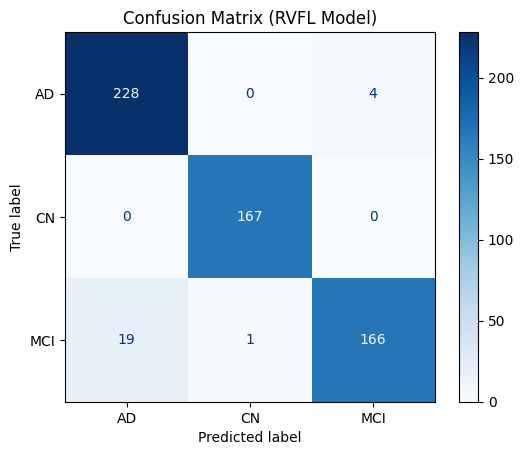

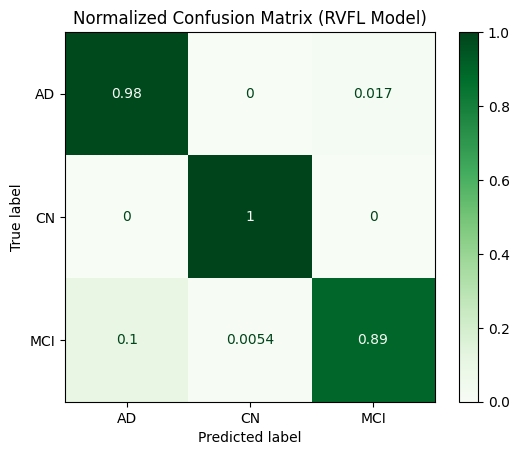

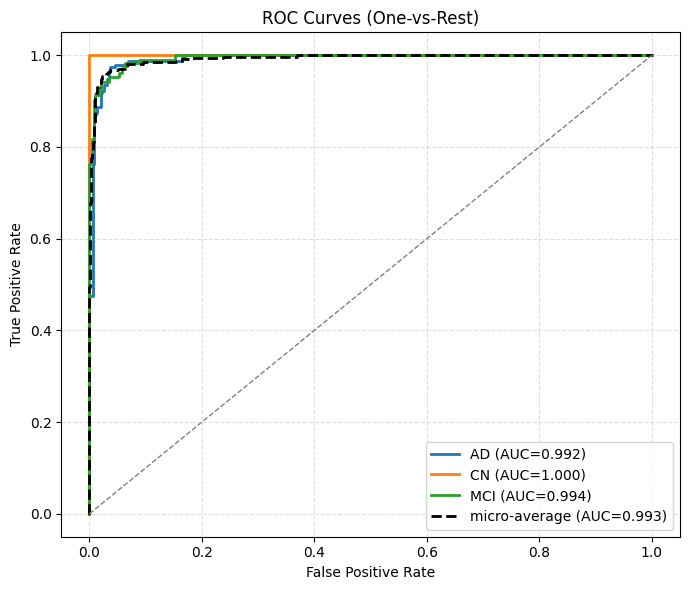

ROC–AUC (weighted, OVR): 0.9949


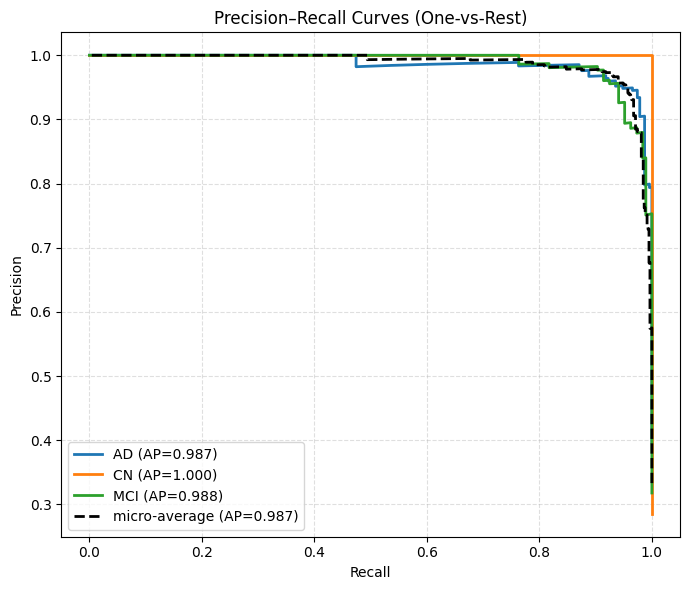

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, cohen_kappa_score, matthews_corrcoef,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize


def evaluate_rvfl_model(model, X_test, y_test, class_names):
    model.eval()
    with torch.no_grad():
        _, pred_logits = model(X_test)
        all_preds = pred_logits.argmax(dim=1).cpu().numpy()
        all_labels = y_test.cpu().numpy()

    # -------------------------
    # Basic Metrics
    # -------------------------
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    # -------------------------
    # Additional Metrics
    # -------------------------
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)

    print("=== 📊 Evaluation Metrics (RVFL Model) ===")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"Cohen's Kappa  : {kappa:.4f}")
    print(f"MCC            : {mcc:.4f}")
    print("\n=== 📋 Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0,digits=6))

    # -------------------------
    # Confusion Matrices
    # -------------------------
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix (RVFL Model)')
    plt.show()

    disp_norm = ConfusionMatrixDisplay.from_predictions(
        all_labels, all_preds, normalize='true', display_labels=class_names, cmap='Greens'
    )
    plt.title('Normalized Confusion Matrix (RVFL Model)')
    plt.show()

    # -------------------------
    # ROC–AUC Curves (multi-class OVR)
    # -------------------------
    try:
        num_classes = len(class_names)
        y_true_bin = label_binarize(all_labels, classes=range(num_classes))
        # Probabilities via softmax
        y_score = torch.softmax(pred_logits, dim=1).cpu().numpy()

        # Per-class ROC curves
        plt.figure(figsize=(7, 6))
        for i in range(num_classes):
            fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
            auc_i = auc(fpr_i, tpr_i)
            plt.plot(fpr_i, tpr_i, lw=2, label=f"{class_names[i]} (AUC={auc_i:.3f})")

        # Micro-average
        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        plt.plot(fpr_micro, tpr_micro, color='black', lw=2, linestyle='--', label=f"micro-average (AUC={auc_micro:.3f})")

        plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves (One-vs-Rest)')
        plt.legend(loc='lower right')
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

        # Numeric Weighted ROC–AUC
        roc_auc = roc_auc_score(y_true_bin, y_score, average='weighted', multi_class='ovr')
        print(f"ROC–AUC (weighted, OVR): {roc_auc:.4f}")
    except Exception as e:
        print(f"ROC–AUC not available: {e}")

    # -------------------------
    # Precision–Recall Curves (optional)
    # -------------------------
    try:
        num_classes = len(class_names)
        y_true_bin = label_binarize(all_labels, classes=range(num_classes))
        y_score = torch.softmax(pred_logits, dim=1).cpu().numpy()

        plt.figure(figsize=(7, 6))
        for i in range(num_classes):
            precision_i, recall_i, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
            ap_i = average_precision_score(y_true_bin[:, i], y_score[:, i])
            plt.plot(recall_i, precision_i, lw=2, label=f"{class_names[i]} (AP={ap_i:.3f})")

        # Micro-average PR
        precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_score.ravel())
        ap_micro = average_precision_score(y_true_bin, y_score, average='micro')
        plt.plot(recall_micro, precision_micro, color='black', lw=2, linestyle='--', label=f"micro-average (AP={ap_micro:.3f})")

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision–Recall Curves (One-vs-Rest)')
        plt.legend(loc='lower left')
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"PR curves not available: {e}")

    print("===========================================")

# Use the tensor versions for evaluation
evaluate_rvfl_model(rvfl_best, X_test_tensor, y_test_tensor, class_names)



Saving model to rvfl_best_model.pth...
Model saved successfully!

Loading model from rvfl_best_model.pth...
Model loaded successfully!

Evaluating loaded model on the test set...
Loaded Model - Test Accuracy: 0.9590, Test Loss: 0.6713

Detailed evaluation for the loaded model:
=== 📊 Evaluation Metrics (RVFL Model) ===
Accuracy       : 0.9590
Precision      : 0.9603
Recall         : 0.9590
F1-score       : 0.9587
Cohen's Kappa  : 0.9377
MCC            : 0.9387

=== 📋 Classification Report ===
              precision    recall  f1-score   support

          AD   0.923077  0.982759  0.951983       232
          CN   0.994048  1.000000  0.997015       167
         MCI   0.976471  0.892473  0.932584       186

    accuracy                       0.958974       585
   macro avg   0.964532  0.958411  0.960527       585
weighted avg   0.960313  0.958974  0.958671       585



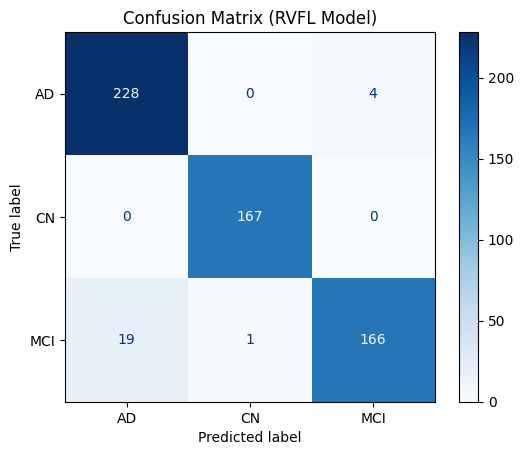

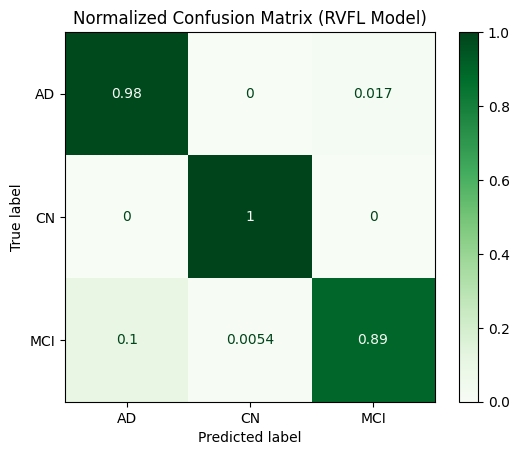

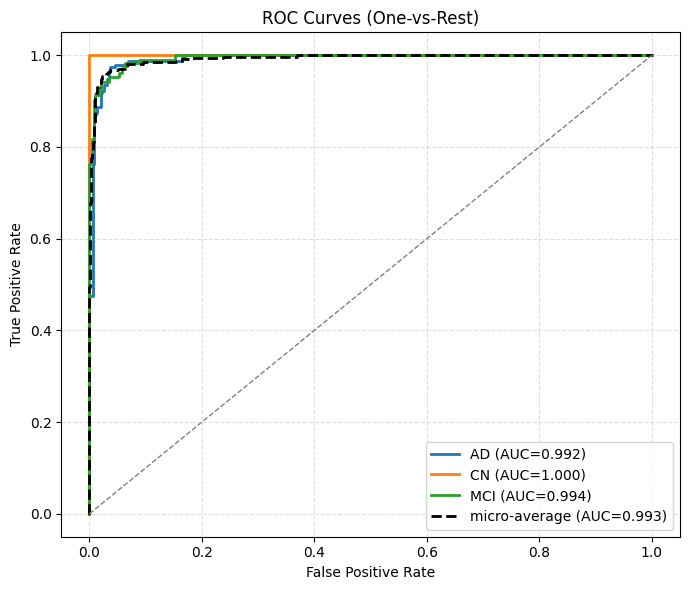

ROC–AUC (weighted, OVR): 0.9949


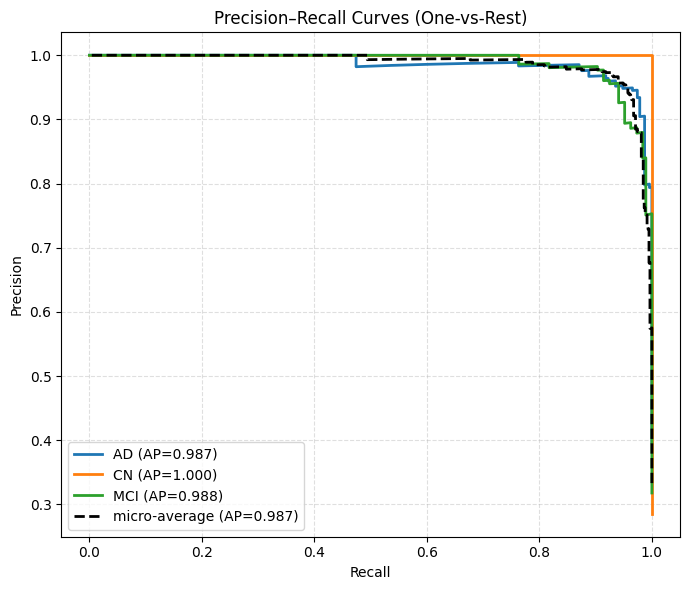

In [ ]:
import torch

# Define the filename for saving the model
model_save_path = 'rvfl_best_model.pth'

# ----------------------------------------------------------
# Save the best model
# ----------------------------------------------------------
print(f"\nSaving model to {model_save_path}...")
torch.save(rvfl_best.state_dict(), model_save_path)
print("Model saved successfully!")

# ----------------------------------------------------------
# Load the model
# ----------------------------------------------------------
print(f"\nLoading model from {model_save_path}...")
# Re-instantiate the model with the best configuration parameters
loaded_rvfl_model = RVFL(INPUT_SIZE, best_config[0], OUTPUT_SIZE).to(device) # input_size, hidden_size, output_size
loaded_rvfl_model.load_state_dict(torch.load(model_save_path))
loaded_rvfl_model.eval() # Set the model to evaluation mode
print("Model loaded successfully!")

# ----------------------------------------------------------
# Use the loaded model for prediction and evaluation
# ----------------------------------------------------------
print("\nEvaluating loaded model on the test set...")
loaded_test_acc, loaded_test_loss = evaluate(loaded_rvfl_model, X_test_tensor, y_test_tensor)
print(f"Loaded Model - Test Accuracy: {loaded_test_acc:.4f}, Test Loss: {loaded_test_loss:.4f}")

# You can also use the evaluate_rvfl_model function for a full report
print("\nDetailed evaluation for the loaded model:")
evaluate_rvfl_model(loaded_rvfl_model, X_test_tensor, y_test_tensor, class_names)
